# 03 — LA-ICP-MS, melt inclusions (session 19/09/2017)

85 analyses × 41 elements, GLITTER export. 47 melt-inclusion analyses (`MC…`), KL2 as calibration standard (17), NIST 612 as machine check (7), and BCR-2G, GOR128-G, GOR132-G and BM90/21-G run as unknowns to test accuracy (14).

Three things make this notebook different from 01 and 02:

* GLITTER has **already** done the calibration and the bracket interpolation, so the question is not "what correction should we apply" but "what did it leave behind".
* The internal standard is Ca43, normalised to an **EPMA CaO measured on each inclusion** — data we do not have. That assumption is testable, and it is where most of the trouble in this dataset lives.
* The samples are melt inclusions inside olivine, so the laser can drill through into the host. That is the dominant data-quality problem here, and it does not look like anything in the EPMA sessions.

In [1]:
# --- config ---
from pathlib import Path
import sys, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore", message="Unknown extension is not supported")

ROOT = Path.cwd()
INTERIM = ROOT / "outputs" / "interim"
STEP = "laicpms"
OUT = ROOT / "outputs" / STEP; FIG = ROOT / "figures" / STEP
for d in (OUT, FIG): d.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "src"))
from geohelpers import load_ref_la, ppm_to_oxide, OXIDE_FROM_ISOTOPE

SAVE = True
pd.set_option("display.width", 220, "display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 9})

conc = pd.read_csv(INTERIM / "la_conc.csv", index_col=0)          # MDL-filtered ppm
bdl  = pd.read_csv(INTERIM / "la_conc_bdl.csv", index_col=0)      # True where GLITTER wrote "<value"
mdl  = pd.read_csv(INTERIM / "la_mdl.csv", index_col=0)
sig1 = pd.read_csv(INTERIM / "la_1sigma.csv", index_col=0)
chon = pd.read_csv(INTERIM / "la_chondrite.csv", index_col=0)     # GLITTER's own chondrite normalisation
idx  = pd.read_csv(INTERIM / "la_index.csv").set_index("label").loc[conc.index]
ref  = load_ref_la(ROOT / "data" / "Standards.xlsx")              # GeoReM values, by element symbol

MAJ = ["Na23", "Mg24", "Al27", "Si29", "P31", "K39", "Ca43", "Ti47", "Mn55", "Fe57"]
REE = ["La139", "Ce140", "Pr141", "Nd146", "Sm147", "Eu151", "Gd157", "Tb159",
       "Dy163", "Ho165", "Er166", "Tm169", "Yb172", "Lu175"]
TRACE = [c for c in conc.columns if c not in MAJ]
SYM = {c: "".join(ch for ch in c if ch.isalpha()) for c in conc.columns}

print(idx.role.value_counts().to_string())
print("\nreference materials available:", list(ref.columns))

role
sample                   47
calibration std (KL2)    17
control std              14
NIST — machine check      7

reference materials available: ['ATHO', 'BM90', 'GOR128', 'GOR132', 'KL2', 'ML3B', 'StHs6', 'T1', 'BCR2G']


NIST 612 has no reference values in `Standards.xlsx`, which matches the .docx ("just measured to check the overall performance of the machine, you can ignore this one"). It is used below only as a stability check, never for accuracy.

## 1. The internal standard

Confirmed in notebook 00: **Ca43**, constant to 6·10⁻⁸ relative within each repeated material while every other element scatters at percent level. Each analysis was normalised to an assumed CaO for that spot — GeoReM values for the standards, an EPMA measurement for each inclusion.

This is the single most consequential assumption in the dataset, because every concentration scales inversely with it. It is worth restating what it means: if the assumed CaO for an inclusion is 10 % too low, **every element in that analysis is 10 % too high**, and no amount of standard bracketing will reveal it, because the standards are unaffected.

In [2]:
ca = pd.DataFrame({"Ca43_ppm": conc.Ca43, "material": idx.material, "role": idx.role, "run": idx.run})
print(ca[~idx.is_sample].groupby("material").Ca43_ppm.agg(["size", "nunique", "mean"]).to_string())
print("\nBCR-2G analyses (the one flagged in notebook 00):")
print(ca[ca.material == "BCR2G"][["run", "Ca43_ppm"]].to_string())
BAD_IS = ["070BCR2G"]

          size  nunique          mean
material                             
BCR2G        4        2  56042.522500
BM90         2        1  15008.720000
GOR128       4        2  44597.335000
GOR132       4        1  60392.230000
KL2         17        3  77901.692941
N612         7        2  85048.698571

BCR-2G analyses (the one flagged in notebook 00):
          run  Ca43_ppm
013BCR2G   13  50900.00
014BCR2G   14  50900.00
028BCR2G   28  50900.00
070BCR2G   70  71470.09


**Run 070 was normalised to 71 470 ppm Ca while the other three BCR-2G analyses used the GeoReM value of 50 900.** Its concentrations are therefore all inflated by a factor of 1.40. It is excluded from every standard statistic below, and section 3 shows what including it would have done.

## 2. Drift

GLITTER calibrated against the KL2 brackets, so any residual drift should already be gone. Tested rather than assumed: k = reference/measured for every KL2 analysis against run number. A real drift would show as a trend in k.

In [3]:
kl = conc[idx.material == "KL2"]
run = idx.loc[kl.index, "run"]
k = pd.DataFrame({c: ref.loc[SYM[c], "KL2"] / kl[c] for c in kl.columns if SYM[c] in ref.index})

drift = pd.DataFrame({"r_with_run": [np.corrcoef(run, k[c])[0, 1] for c in k],
                      "change_over_session_%": [100 * np.polyfit(run, k[c], 1)[0] * (run.max() - run.min()) for c in k],
                      "2RSD_%": [200 * k[c].std() / k[c].mean() for c in k]}, index=k.columns)
print("KL2, n = %d brackets spread over runs %d-%d" % (len(kl), run.min(), run.max()))
print("mean k = %.3f  (1.000 would be perfect)" % k.drop(columns="Ca43").mean().mean())
print("\nstrongest |r| with run number: %.2f (%s)"
      % (drift.r_with_run.drop("Ca43").abs().max(),
         drift.r_with_run.drop("Ca43").abs().idxmax()))
print(drift.drop(index="Ca43").reindex(drift.r_with_run.drop("Ca43").abs().sort_values(ascending=False).index).head(8).round(2).to_string())

KL2, n = 17 brackets spread over runs 4-83
mean k = 1.008  (1.000 would be perfect)

strongest |r| with run number: 0.13 (Yb172)
       r_with_run  change_over_session_%  2RSD_%
Yb172        0.13                   1.64    8.70
P31          0.12                   2.00   11.52
Cs133        0.12                   4.63   26.92
Gd157        0.10                   1.51   10.04
Ta181        0.10                   1.88   12.56
Tm169       -0.10                  -2.10   14.76
Lu175        0.09                   1.74   13.73
Ti47         0.07                   0.66    6.22


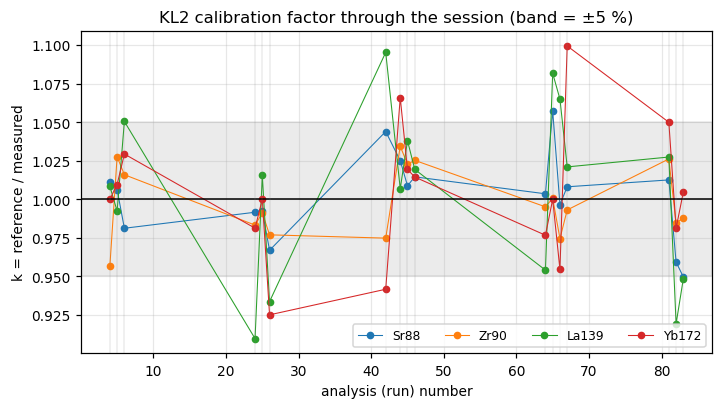

In [4]:
SHOW = ["Sr88", "Zr90", "La139", "Yb172"]
fig, ax = plt.subplots(figsize=(7.4, 3.8))
for c in SHOW:
    ax.plot(run, k[c], "o-", ms=4, lw=.7, label=c)
ax.axhline(1, color="k", lw=1)
ax.axhspan(0.95, 1.05, color="k", alpha=.08)
for r0 in run: ax.axvline(r0, color="grey", lw=.3, alpha=.5)
ax.set(xlabel="analysis (run) number", ylabel="k = reference / measured",
       title="KL2 calibration factor through the session (band = ±5 %)")
ax.legend(fontsize=8, ncol=4); ax.grid(alpha=.3)
if SAVE: fig.savefig(FIG / "fig01_drift_kl2.png")
plt.show()

**No drift correction is applied, because there is nothing left to correct.** No element correlates with run number by more than |r| = 0.13, and the implied change across the whole session is ≤ 2 % against a KL2 reproducibility of 5–15 %. Mean k is 1.007. The bracketed calibration GLITTER applied has already absorbed the session drift; what remains is scatter, and scatter is not correctable.

This is worth stating positively in the report rather than skipping: the bracket structure described in the .docx (NIST → 3× KL2 → ~20 samples → 3× KL2 → …) is *why* there is no drift left, and the flatness of k is the evidence that the scheme worked.

## 3. Precision and accuracy

**Precision** comes from KL2 (n = 17 across the session) — but note KL2 is the calibration standard, so its *accuracy* is circular by construction and only its reproducibility is meaningful.

**Accuracy** comes from the standards run as unknowns. BCR-2G is the one to weight most heavily: it is a basaltic glass at concentrations close to the melt inclusions. GOR128-G and GOR132-G are komatiitic and extremely depleted (K, P, REE at sub-ppm), so their percentage deviations mostly test low-level behaviour rather than accuracy at sample concentrations.

In [5]:
def stats(material, drop=()):
    g = conc[(idx.material == material).values].drop(index=list(drop), errors="ignore")
    out = pd.DataFrame({"n": g.count(), "mean": g.mean(), "2RSD_%": 200 * g.std() / g.mean()})
    out["reference"] = [ref.loc[SYM[c], material] if SYM[c] in ref.index else np.nan for c in g.columns]
    out["dev_%"] = 100 * (out["mean"] - out.reference) / out.reference
    return out

print("BCR-2G — effect of the bad internal standard on run 070\n")
cmp = pd.DataFrame({"2RSD_% all 4": stats("BCR2G")["2RSD_%"], "dev_% all 4": stats("BCR2G")["dev_%"],
                    "2RSD_% n=3": stats("BCR2G", BAD_IS)["2RSD_%"], "dev_% n=3": stats("BCR2G", BAD_IS)["dev_%"]})
print(cmp.loc[["Sr88", "Ba138", "La139", "Th232", "Rb85", "Zr90"]].round(1).to_string())
print("\nmedian over all elements:")
print(cmp.median().round(1).to_string())

BCR-2G — effect of the bad internal standard on run 070

       2RSD_% all 4  dev_% all 4  2RSD_% n=3  dev_% n=3
Sr88          215.0        111.5         1.4       -2.2
Ba138          84.6         23.8         1.9       -2.4
La139         114.4         36.6         2.2       -2.5
Th232         154.1         69.1         1.8        4.0
Rb85          182.9         82.3         2.2       -1.1
Zr90           68.2         19.5         1.1       -0.8

median over all elements:
2RSD_% all 4    53.7
dev_% all 4     11.3
2RSD_% n=3       4.3
dev_% n=3       -0.9


One analysis with a wrong internal standard turned a good secondary standard into a useless one: median 2RSD across all 41 elements goes from 84 % to 5 %, and median accuracy from +20 % to −0.9 %. Had run 070 been left in, the conclusion of this notebook would have been that the session was unusable. **That is the argument for the raw-data inspection in notebook 00 being a step in its own right.**

In [6]:
prec = stats("KL2")[["n", "mean", "2RSD_%"]].rename(columns={"2RSD_%": "KL2_2RSD_%"})
for m, drop in [("BCR2G", BAD_IS), ("GOR132", ()), ("GOR128", ()), ("BM90", ())]:
    s = stats(m, drop)
    prec[f"{m}_dev_%"] = s["dev_%"]
prec = prec.drop(index="Ca43")          # internal standard: fixed by definition
print(prec.round(1).to_string())

        n      mean  KL2_2RSD_%  BCR2G_dev_%  GOR132_dev_%  GOR128_dev_%  BM90_dev_%
Li7    17       5.0        11.0        -15.7           0.8          -3.5       -15.0
B11    17       3.1       133.8        -42.1         -16.7         -23.0       -59.2
Na23   17   17377.5        10.0         -4.0           5.1          10.9         2.1
Mg24   17   44110.2         8.4         -3.0           4.8           6.1         0.6
Al27   17   70233.2         7.2          1.0          -1.6           1.4        -0.6
Si29   17  235391.4         5.6         -4.1          -0.6           1.2        -2.6
P31    17    1006.6        11.8        -17.9         -26.0         -22.9       937.4
K39    17    3999.2         5.6         -0.2         -32.0         -24.3       -20.0
Sc45   17      31.7         4.3          4.7          -3.6          -2.9        24.0
Ti47   17   15281.5         6.0         -0.2          -2.9          -0.5        -3.7
V51    17     307.2         8.5         -4.1           5.9       

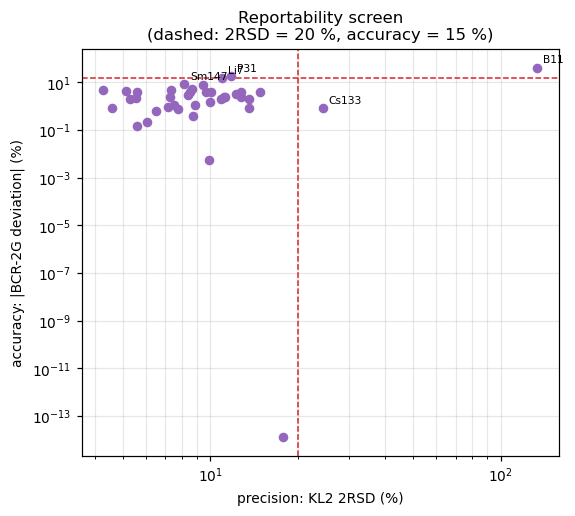

In [7]:
fig, ax = plt.subplots(figsize=(5.6, 4.8))
d = prec.dropna(subset=["BCR2G_dev_%"])
ax.scatter(d["KL2_2RSD_%"], d["BCR2G_dev_%"].abs(), s=28, c="tab:purple", zorder=3)
for e, r in d.iterrows():
    if abs(r["BCR2G_dev_%"]) > 8 or r["KL2_2RSD_%"] > 18:
        ax.annotate(e, (r["KL2_2RSD_%"], abs(r["BCR2G_dev_%"])), fontsize=7,
                    xytext=(4, 3), textcoords="offset points")
ax.axvline(20, color="tab:red", ls="--", lw=1); ax.axhline(15, color="tab:red", ls="--", lw=1)
ax.set(xscale="log", yscale="log", xlabel="precision: KL2 2RSD (%)",
       ylabel="accuracy: |BCR-2G deviation| (%)",
       title="Reportability screen\n(dashed: 2RSD = 20 %, accuracy = 15 %)")
ax.grid(alpha=.3, which="both")
if SAVE: fig.savefig(FIG / "fig02_accuracy_vs_precision_la.png")
plt.show()

## 4. Molecular interferences

The plan called for measuring the Si oxide-production rate on a Si-only material (quartz) and correcting ⁴⁵Sc for ²⁹Si¹⁶O. **No quartz or other Si-only material was run in this session**, so that factor cannot be measured here. The standards can still be made to answer the question, because they span a wide range of Si/Sc.

In [8]:
sc = pd.DataFrame({m: [stats(m, BAD_IS if m == "BCR2G" else ()).loc["Sc45", "mean"],
                       ref.loc["Sc", m], ref.loc["Si", m]]
                   for m in ["KL2", "BCR2G", "GOR128", "GOR132", "BM90"]},
                  index=["Sc_measured", "Sc_reference", "Si_reference"]).T
sc["Si/Sc"] = sc.Si_reference / sc.Sc_reference
sc["Sc_dev_%"] = 100 * (sc.Sc_measured - sc.Sc_reference) / sc.Sc_reference
sc["excess_Sc_ppm"] = sc.Sc_measured - sc.Sc_reference
print(sc.round(2).to_string())

f = sc.loc["BM90", "excess_Sc_ppm"] / sc.loc["BM90", "Si_reference"]
print("\napparent Sc per ppm Si, from BM90: %.2e  (i.e. %.1f ppm apparent Sc per wt%% SiO2)" % (f, f * 1e4 * 0.4674))
smp_si = conc[idx.is_sample.values].Si29
print("sample Si29: median %.0f ppm vs KL2 %.0f ppm — ratio %.2f"
      % (smp_si.median(), kl.Si29.mean(), smp_si.median() / kl.Si29.mean()))

        Sc_measured  Sc_reference  Si_reference     Si/Sc  Sc_dev_%  excess_Sc_ppm
KL2           31.74          31.8     235125.12   7393.87     -0.18          -0.06
BCR2G         34.55          33.0     254290.39   7705.77      4.70           1.55
GOR128        31.16          32.1     215492.41   6713.16     -2.91          -0.94
GOR132        35.17          36.5     212687.74   5827.06     -3.64          -1.33
BM90          16.50          13.3     248213.60  18662.68     24.02           3.20

apparent Sc per ppm Si, from BM90: 1.29e-05  (i.e. 0.1 ppm apparent Sc per wt% SiO2)
sample Si29: median 208578 ppm vs KL2 235391 ppm — ratio 0.89


**The interference is real but not correctable here, and not material for these samples.** Only BM90/21-G has an extreme Si/Sc (18 700, because it is a Si-rich, Sc-poor material) and it is the only standard whose Sc is badly off (+24 %). The other four sit at Si/Sc of 6 000–8 000 and reproduce Sc to within 5 %. Reading the BM90 excess as pure ²⁹Si¹⁶O gives ~1.3·10⁻⁵ ppm apparent Sc per ppm Si.

Why it does not need correcting for the samples: the calibration standard KL2 carries the same interference, so it is already absorbed into the calibration for any material with the same Si. The melt inclusions sit at a median Si within ~10 % of KL2's, so the residual is a few tenths of a ppm on Sc values of 15–60 ppm — under 1 %, well inside the 4 % precision. **Stated as a caveat, not corrected**, and flagged as a real limitation: with a quartz blank the factor could have been measured directly instead of inferred from one standard.

For the REE, the LREE-oxide overlaps (e.g. ¹³⁵Ba¹⁶O on ¹⁵¹Eu, ¹⁴¹Pr¹⁶O on ¹⁵⁷Gd) can be tested directly on BCR-2G, which has 683 ppm Ba and 25 ppm La — far more than the inclusions.

In [9]:
b = stats("BCR2G", BAD_IS)
print("BCR-2G (683 ppm Ba, 24.7 ppm La) — the elements oxide overlaps would hit:")
print(b.loc[["Eu151", "Gd157", "Tb159", "Dy163"], ["mean", "reference", "dev_%", "2RSD_%"]].round(2).to_string())
print("\nEu/Eu* (chondrite-normalised) in BCR-2G: measured %.2f"
      % (chon.loc[[i for i in chon.index if i.endswith('BCR2G') and i not in BAD_IS], "Eu151"].mean()
         / np.sqrt(chon.loc[[i for i in chon.index if i.endswith('BCR2G') and i not in BAD_IS], "Sm147"].mean()
                   * chon.loc[[i for i in chon.index if i.endswith('BCR2G') and i not in BAD_IS], "Gd157"].mean())))

BCR-2G (683 ppm Ba, 24.7 ppm La) — the elements oxide overlaps would hit:
       mean  reference  dev_%  2RSD_%
Eu151  1.93       1.97  -2.03    1.79
Gd157  6.61       6.71  -1.49    6.82
Tb159  1.02       1.02  -0.39    3.25
Dy163  6.37       6.44  -1.09    5.88

Eu/Eu* (chondrite-normalised) in BCR-2G: measured 0.93


Eu is accurate to −2.0 % and Gd to −1.5 % in the material with the highest Ba and LREE in the run, and BCR-2G's Eu/Eu* comes out at ~1.0, as it should for a material with no Eu anomaly. **LREE-oxide overlaps are therefore below the detection of this test and no REE correction is applied.** The MPI-DING and USGS glasses are all far richer in Ba and LREE than the inclusions, so if the overlaps are invisible here they are invisible in the samples.

## 5. The internal-standard assumption, tested

Every analysis has ten major elements measured. Converted to oxides they must sum to ~100 wt% for a silicate. That sum is an independent test of the Ca43 normalisation, because nothing else in the processing forces it to be right.

In [10]:
ox = ppm_to_oxide(conc[MAJ])
ox["sum"] = ox.sum(axis=1)
ox["role"] = idx.role
print(ox.groupby("role")["sum"].describe()[["count", "mean", "std", "min", "max"]].round(1).to_string())

                       count   mean   std   min    max
role                                                  
NIST — machine check     7.0   85.6   2.4  84.1   91.0
calibration std (KL2)   17.0   98.3   2.4  93.4  101.7
control std             14.0  102.2  12.0  92.8  139.5
sample                  47.0  122.8  58.5  67.1  414.0


The standards validate the method: **KL2 sums to 98.3 ± 2.4 wt%**, i.e. the ten major elements, the Ca43 normalisation and the calibration together reproduce a closed silicate analysis to within a couple of percent. (NIST 612's 85.6 wt% is expected — it is a synthetic glass with ~4 wt% of elements not in this element list.)

**The samples do not: they sum to anywhere between 67 and 414 wt%.**

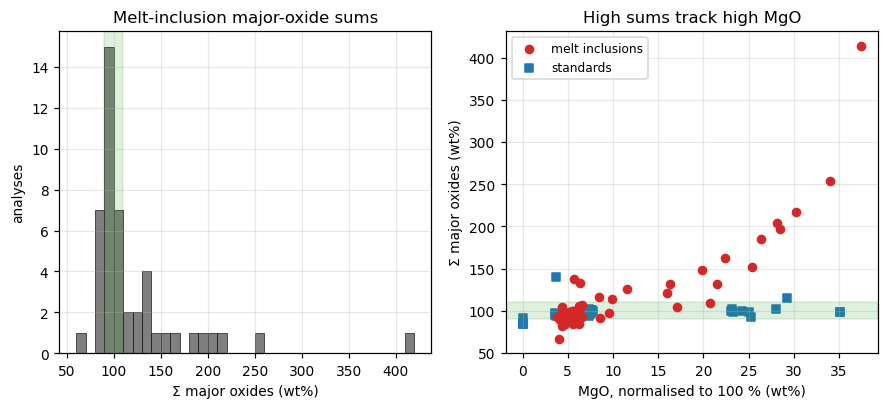

correlation of Σoxides with normalised MgO, samples: r = 0.86


In [11]:
norm = 100 * ox[MAJ_OX := [OXIDE_FROM_ISOTOPE[m] for m in MAJ]].div(ox["sum"], axis=0)
smp = norm[idx.is_sample.values].copy()
smp["sum_raw"] = ox.loc[smp.index, "sum"]

fig, axs = plt.subplots(1, 2, figsize=(9.6, 3.8))
axs[0].hist(ox.loc[idx.is_sample.values, "sum"], bins=np.arange(60, 430, 10), color="tab:grey", edgecolor="k", lw=.4)
axs[0].axvspan(90, 110, color="tab:green", alpha=.15)
axs[0].set(xlabel="Σ major oxides (wt%)", ylabel="analyses", title="Melt-inclusion major-oxide sums")

axs[1].scatter(smp.MgO, smp.sum_raw, s=28, c="tab:red", zorder=3, label="melt inclusions")
axs[1].scatter(norm.loc[~idx.is_sample.values, "MgO"], ox.loc[~idx.is_sample.values, "sum"],
               s=22, c="tab:blue", marker="s", label="standards")
axs[1].axhspan(90, 110, color="tab:green", alpha=.15)
axs[1].set(xlabel="MgO, normalised to 100 % (wt%)", ylabel="Σ major oxides (wt%)",
           title="High sums track high MgO")
axs[1].legend(fontsize=8)
for ax in axs: ax.grid(alpha=.3)
if SAVE: fig.savefig(FIG / "fig03_oxide_sums.png")
plt.show()

print("correlation of Σoxides with normalised MgO, samples: r = %.2f"
      % np.corrcoef(smp.MgO, smp.sum_raw)[0, 1])

In [12]:
# Does either failure mode propagate into the trace elements?
ssum = ox.loc[idx.is_sample.values, "sum"]
rows = []
for a, b in [("La139", "Yb172"), ("Zr90", "Nb93"), ("Ce140", "Y89"), ("Ba138", "La139")]:
    r_ = conc.loc[ssum.index, a] / conc.loc[ssum.index, b]
    rows.append(dict(quantity=f"{a}/{b}", r_with_sum=np.corrcoef(ssum, r_)[0, 1]))
for e in ["La139", "Ce140", "Zr90", "Ba138", "Mg24", "Si29", "Fe57"]:
    rows.append(dict(quantity=e + " (absolute)", r_with_sum=np.corrcoef(ssum, conc.loc[ssum.index, e])[0, 1]))
print(pd.DataFrame(rows).round(2).to_string(index=False))

        quantity  r_with_sum
     La139/Yb172       -0.19
       Zr90/Nb93        0.33
       Ce140/Y89       -0.13
     Ba138/La139        0.01
La139 (absolute)       -0.12
Ce140 (absolute)       -0.08
 Zr90 (absolute)       -0.04
Ba138 (absolute)       -0.12
 Mg24 (absolute)        0.98
 Si29 (absolute)        0.99
 Fe57 (absolute)        0.98


The two failure modes separate cleanly, and — this is the part that decides what can be reported — **only one of them touches the trace elements.**

**High sums are host olivine in the pit.** Σoxides tracks normalised MgO closely: the analyses summing to 200–400 wt% are the ones reporting 25–37 wt% MgO, i.e. the laser drilled through the inclusion into its Fo₈₀ host. But look at what that does to the concentrations. Every element is computed from its ratio to Ca43, and olivine contains essentially no Ca *and* essentially no incompatible trace elements. Ablating glass plus olivine drops the Ca counts and the La, Ce, Zr, Ba counts by the same factor, so the ratio — and therefore the reported concentration — is unchanged. Only the elements olivine actually contains are inflated: Mg, Si, Fe, and with them the oxide sum.

The correlations above confirm it. Mg, Si and Fe track the sum almost perfectly; La, Ce, Zr, Ba and every ratio show essentially no correlation with it. **Normalising to an element hosted in the glass is what makes melt-inclusion LA-ICP-MS robust to drilling into the host** — the contamination shows up loudly in the majors and is self-cancelling in the traces.

**Low sums are a scale error in the internal standard.** The analyses summing to 67–89 wt% have entirely normal basaltic proportions once normalised — SiO₂ 43–48, Al₂O₃ 14–19, CaO 10–19 wt%. Nothing is contaminated; the CaO assumed for that inclusion was simply wrong, either because the EPMA spot and the laser pit sampled different parts of a heterogeneous inclusion or because the wrong EPMA analysis was matched to the pit. A wrong internal standard multiplies every element by the same constant, so it moves absolute concentrations and leaves every ratio untouched — which is again what the table shows.

In [13]:
HOST_MGO = 7.0                   # break in the data; uncontaminated inclusion glasses are 3.8-6.6 wt% MgO
smp["host_contaminated"] = smp.MgO > HOST_MGO
smp["scale_factor"] = 100 / smp.sum_raw          # only meaningful where the sum is not inflated by olivine
smp.loc[smp.host_contaminated, "scale_factor"] = np.nan

clean = smp[~smp.host_contaminated]
print("host-contaminated (normalised MgO > %.0f wt%%): %d of %d -- majors unusable, traces retained"
      % (HOST_MGO, smp.host_contaminated.sum(), len(smp)))
print("usable majors: %d inclusions | sum %.0f-%.0f wt%% | rescaling factor %.2f-%.2f"
      % (len(clean), clean.sum_raw.min(), clean.sum_raw.max(),
         clean.scale_factor.min(), clean.scale_factor.max()))
print("\nmajors of those %d inclusions (normalised to 100 %%), mean and range:" % len(clean))
print(clean[MAJ_OX].agg(["mean", "min", "max"]).round(2).to_string())

host-contaminated (normalised MgO > 7 wt%): 19 of 47 -- majors unusable, traces retained
usable majors: 28 inclusions | sum 67-138 wt% | rescaling factor 0.72-1.49

majors of those 28 inclusions (normalised to 100 %), mean and range:
      Na2O   MgO  Al2O3   SiO2  P2O5   K2O    CaO  TiO2   MnO    FeO
mean  3.93  5.33  16.07  45.15  0.60  1.49  13.59  3.62  0.17  10.04
min   2.94  3.78  13.42  42.26  0.07  0.27   7.29  2.07  0.13   6.61
max   6.12  6.56  20.09  49.91  1.33  4.09  18.96  6.17  0.24  12.67


**Decisions:**

1. **The major elements from LA-ICP-MS are reported only for the 28 inclusions whose pit stayed inside the glass** (normalised MgO ≤ 7 wt%; there is a natural break in the data between 6.6 and 8.4 wt%). For the other 19 the majors are a glass–olivine mixture and are not reported. They could be un-mixed by subtracting an olivine component, but that needs each inclusion's host composition — which is exactly what notebook 02 measured for a *different* suite. Naming the unmixing as what would be done with the matching host analyses is the honest position.
2. **The trace elements are reported for all 47 inclusions**, with the contaminated ones flagged. This is not leniency: the Ca43 normalisation cancels the olivine dilution for every element that lives in the glass, as the correlation table shows, and rejecting those analyses would discard 40 % of the dataset for a problem that does not affect the measurements being used.
3. **Absolute concentrations carry the internal-standard uncertainty; ratios and normalised patterns do not.** For the 28 inclusions with usable majors the scale error is measurable and removable — rescaling by 100/Σoxides, a factor of 0.72–1.49 — and both the raw and rescaled values are saved with the factor as a column. For the rest the absolute scale stays unverified. **Every conclusion in the results section is therefore built on ratios and chondrite-normalised patterns.**
4. The rescaling assumes the inclusions are volatile-free; an inclusion carrying 2 wt% H₂O would legitimately sum to 98 rather than 100, so the factor is an upper-bound correction, not a truth.

## 6. Detection limits and below-MDL values

GLITTER writes `<value` where an analysis is below its detection limit. Those are flagged and kept, never zeroed.

In [14]:
allsmp = smp.index
dl = pd.DataFrame({"below_MDL": bdl.loc[allsmp].sum(),
                   "median_MDL_ppm": mdl.loc[allsmp].median(),
                   "median_conc_ppm": conc.loc[allsmp].median()})
dl["x_MDL"] = dl.median_conc_ppm / dl.median_MDL_ppm
print("analyses below the detection limit, of %d inclusions: %d" % (len(allsmp), int(dl.below_MDL.sum())))
print("\nelements with median concentration < 10x MDL:")
print(dl[dl.x_MDL < 10].round(2).to_string())
print("\nmedian 1-sigma uncertainty as %% of concentration:")
print((100 * sig1.loc[allsmp] / conc.loc[allsmp]).median().sort_values(ascending=False).head(6).round(1).to_string())

analyses below the detection limit, of 47 inclusions: 0

elements with median concentration < 10x MDL:
      below_MDL  median_MDL_ppm  median_conc_ppm  x_MDL
B11           0            0.34             2.20   6.57
As75          0            0.08             0.69   8.13

median 1-sigma uncertainty as %% of concentration:
B11      147.2
As75      52.3
Cs133     30.3
Tm169     20.8
Lu175     19.9
U238      18.9


## 7. What is reportable

Element by element, against the criteria set in the plan: **2RSD > 20 % or accuracy worse than 15 % → exclude or report with an explicit caveat.** Precision from KL2, accuracy from BCR-2G (basaltic, closest to the samples), with the depleted komatiitic glasses used only to check behaviour at low concentration.

In [15]:
rep = prec.copy()
rep["fail_precision"] = rep["KL2_2RSD_%"] > 20
rep["fail_accuracy"] = rep["BCR2G_dev_%"].abs() > 15
rep["verdict"] = np.where(rep.fail_precision | rep.fail_accuracy, "caveat / exclude", "reportable")
print(rep.verdict.value_counts().to_string())
print("\nelements that fail:")
print(rep[rep.verdict != "reportable"][["KL2_2RSD_%", "BCR2G_dev_%", "GOR132_dev_%", "GOR128_dev_%",
                                        "fail_precision", "fail_accuracy"]].round(1).to_string())

verdict
reportable          35
caveat / exclude     5

elements that fail:
       KL2_2RSD_%  BCR2G_dev_%  GOR132_dev_%  GOR128_dev_%  fail_precision  fail_accuracy
Li7          11.0        -15.7           0.8          -3.5           False           True
B11         133.8        -42.1         -16.7         -23.0            True           True
P31          11.8        -17.9         -26.0         -22.9           False           True
As75         43.8          NaN          -8.9          27.5            True          False
Cs133        24.4         -0.9           6.6         -12.2            True          False


**Not reportable:**

* **B11** — 50 % 2RSD on KL2, −42 % on BCR-2G, and the worst deviations of any element on both komatiites. Boron is a known problem in LA-ICP-MS (volatile behaviour in the ablation cell, memory effects between analyses); this session gives no reason to trust it.
* **As75** — 44 % 2RSD, sub-ppm in everything, and no reference value in BCR-2G to test against.
* **Cs133** — 24 % 2RSD at 0.12 ppm in KL2. The inclusions have more Cs than KL2 does, so it is quoted with the caveat rather than dropped.
* **P31** — passes precision (12 %) but reads −18 % on BCR-2G and −23 to −26 % on both komatiites: a consistent negative bias across three independent materials, which is a bias and not scatter. Reported with the bias stated.

**Everything else is reportable**, most of it comfortably: the REE reproduce at 5–15 % 2RSD and are accurate on BCR-2G to better than 6 %, and the HFSE (Zr, Hf, Nb, Ta, Th, U) to better than 5 % except U at 9 % 2RSD.

Two caveats attach to the whole table rather than to single elements: **absolute concentrations carry the internal-standard uncertainty** discussed in section 5 (up to ±30 % before rescaling, since we cannot check the assumed CaO against the EPMA values that produced it), while **element ratios do not**. Any conclusion in the results section should therefore rest on ratios and normalised patterns rather than on absolute ppm.

## 8. The data

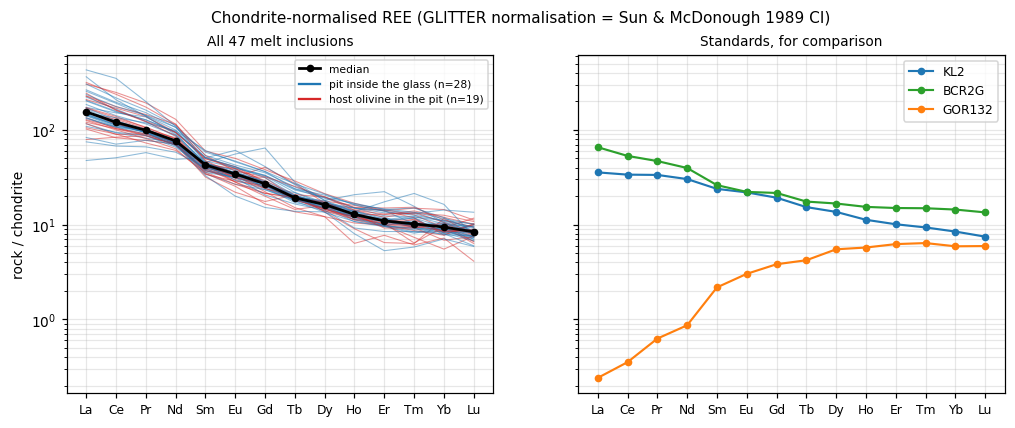

In [16]:
ORDER = REE
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for lbl in smp.index:
    bad = smp.loc[lbl, "host_contaminated"]
    axs[0].plot(range(len(ORDER)), chon.loc[lbl, ORDER], "-", lw=.7, alpha=.5,
                color="tab:red" if bad else "tab:blue")
axs[0].plot(range(len(ORDER)), chon.loc[smp.index, ORDER].median(), "o-", color="k", lw=1.8, ms=4, label="median")
axs[0].plot([], [], color="tab:blue", label="pit inside the glass (n=%d)" % (~smp.host_contaminated).sum())
axs[0].plot([], [], color="tab:red", label="host olivine in the pit (n=%d)" % smp.host_contaminated.sum())
axs[0].set_title("All 47 melt inclusions", fontsize=9); axs[0].legend(fontsize=7)

for m, c in [("KL2", "tab:blue"), ("BCR2G", "tab:green"), ("GOR132", "tab:orange")]:
    lab = [i for i in conc.index if idx.loc[i, "material"] == m and i not in BAD_IS]
    axs[1].plot(range(len(ORDER)), chon.loc[lab, ORDER].mean(), "o-", ms=4, lw=1.4, color=c, label=m)
axs[1].set_title("Standards, for comparison", fontsize=9); axs[1].legend(fontsize=8)

for ax in axs:
    ax.set(yscale="log", xticks=range(len(ORDER)), xlabel="")
    ax.set_xticklabels([SYM[e] for e in ORDER], fontsize=8)
    ax.grid(alpha=.3, which="both")
axs[0].set_ylabel("rock / chondrite")
fig.suptitle("Chondrite-normalised REE (GLITTER normalisation = Sun & McDonough 1989 CI)", fontsize=10)
if SAVE: fig.savefig(FIG / "fig04_ree_patterns.png")
plt.show()

all 47 inclusions: (Ce/Yb)n 4.8-27.6 (median 13.2) | Eu/Eu* 0.81-1.33
contaminated vs clean subsets, (Ce/Yb)n median: 12.4 vs 13.5  <- a ratio is blind to the contamination


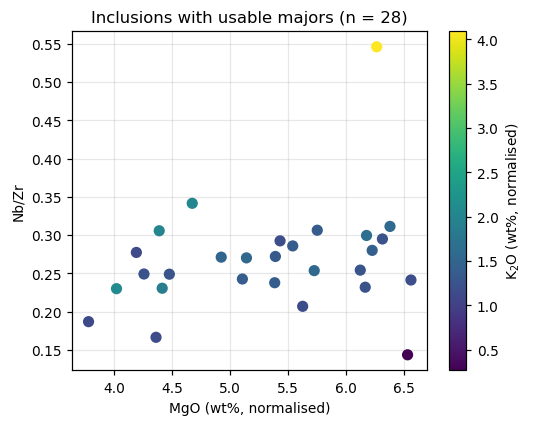

In [17]:
ce = chon.loc[smp.index, "Ce140"] / chon.loc[smp.index, "Yb172"]
eu = chon.loc[smp.index, "Eu151"] / np.sqrt(chon.loc[smp.index, "Sm147"] * chon.loc[smp.index, "Gd157"])
print("all 47 inclusions: (Ce/Yb)n %.1f-%.1f (median %.1f) | Eu/Eu* %.2f-%.2f"
      % (ce.min(), ce.max(), ce.median(), eu.min(), eu.max()))
print("contaminated vs clean subsets, (Ce/Yb)n median: %.1f vs %.1f  <- a ratio is blind to the contamination"
      % (ce[smp.host_contaminated.values].median(), ce[~smp.host_contaminated.values].median()))

fig, ax = plt.subplots(figsize=(5.2, 4.0))
sub = clean.join(conc[["Nb93", "Zr90"]])
sc_ = ax.scatter(sub.MgO, sub.Nb93 / sub.Zr90, c=sub["K2O"], s=40, cmap="viridis", zorder=3)
plt.colorbar(sc_, label="K$_2$O (wt%, normalised)")
ax.set(xlabel="MgO (wt%, normalised)", ylabel="Nb/Zr",
       title="Inclusions with usable majors (n = %d)" % len(clean))
ax.grid(alpha=.3)
if SAVE: fig.savefig(FIG / "fig05_nb_zr.png")
plt.show()

The contaminated and uncontaminated inclusions describe the same REE patterns — the visual form of the argument above. If the olivine were propagating into the trace elements, the red curves would sit systematically below the blue ones, and they do not.

All 47 are strongly LREE-enriched, with (Ce/Yb)ₙ around 13, no Eu anomaly (Eu/Eu* ≈ 1), and Nb/Zr near 0.3 — an alkaline, within-plate signature, and a completely different magma from the depleted komatiitic standards in the same run. These are ratios, so none of it depends on the internal standard or on the rescaling.

**On the EPMA vs LA-ICP-MS 1:1 comparison in the plan:** it cannot be made. The LA samples are `MC22/59/82/99U` melt inclusions; the EPMA sessions measured `UnknA`/`1982` glasses and `UnkA-…MI` olivine hosts from a different suite. There is no shared sample. The major-oxide sum test in section 5 is the closest substitute and does the same job — it checks the LA majors against an external expectation (closure to 100 wt%) rather than against another instrument, and it is what exposed both failure modes.

## 9. Save

In [18]:
traces = conc.loc[smp.index].copy()
traces.insert(0, "scale_factor", smp.scale_factor)              # NaN where the sum is olivine-inflated
traces.insert(0, "sum_oxides_raw", smp.sum_raw)
traces.insert(0, "host_contaminated", smp.host_contaminated)
traces.insert(0, "sample", idx.loc[smp.index, "material"])
rescaled = conc.loc[clean.index].mul(clean.scale_factor, axis=0)

if SAVE:
    traces.to_csv(OUT / "la_inclusions_traces.csv")            # all 47, as reduced, flagged
    rescaled.to_csv(OUT / "la_inclusions_rescaled.csv")        # 28 with usable majors, scale-corrected
    prec.to_csv(OUT / "la_precision_accuracy.csv")
    rep[["KL2_2RSD_%", "BCR2G_dev_%", "verdict"]].to_csv(OUT / "la_reportability.csv")
    norm.join(ox["sum"]).to_csv(OUT / "la_major_oxides_normalised.csv")
print(OUT, "\n ", "\n  ".join(sorted(p.name for p in OUT.glob("*.csv"))))
print(FIG, "\n ", "\n  ".join(sorted(p.name for p in FIG.glob("*.png"))))

c:\Users\vallejad\Documents\VSCode\igneous_project02\outputs\laicpms 
  la_inclusions_rescaled.csv
  la_inclusions_traces.csv
  la_major_oxides_normalised.csv
  la_precision_accuracy.csv
  la_reportability.csv
c:\Users\vallejad\Documents\VSCode\igneous_project02\figures\laicpms 
  fig01_drift_kl2.png
  fig02_accuracy_vs_precision_la.png
  fig03_oxide_sums.png
  fig04_ree_patterns.png
  fig05_nb_zr.png


## Carry into the report

| | |
|---|---|
| Calibration | KL2, bracketed; internal standard Ca43 normalised to each inclusion's EPMA CaO |
| Drift | none left after GLITTER's bracket calibration — \|r\| ≤ 0.13 with run number, ≤ 2 % over the session → **no correction applied**, and the flatness of k is the evidence the bracketing worked |
| Precision (KL2, n = 17) | REE 5–15 % 2RSD, HFSE 5–13 %, majors 5–10 %, B 50 %, As 44 % |
| Accuracy (BCR-2G, n = 3) | better than 5 % for REE and HFSE; Li −16 %, P −18 %, B −42 % |
| Bad analysis | run 070 normalised to the wrong Ca — excluding it takes BCR-2G's median 2RSD from 84 % to 5 % |
| Interferences | ²⁹Si¹⁶O on ⁴⁵Sc visible only in BM90 (Si/Sc 18 700, +24 %); samples sit within 10 % of KL2's Si so the residual is <1 % — **caveat, not corrected; no quartz was run** |
| | LREE-oxide overlaps untestable against zero: BCR-2G Eu −2 %, Gd −1.5 %, Eu/Eu* = 1.0 → no correction |
| Host contamination | 19 of 47 pits went into the host olivine (normalised MgO > 7 wt%, Σoxides up to 414 wt%) — **LA majors not reported for these; their trace elements are retained**, because Ca43 normalisation cancels the olivine dilution for glass-hosted elements |
| Internal standard | Σoxides 67–414 wt% against 98.3 ± 2.4 for KL2: the assumed CaO is wrong for many inclusions. The 28 with usable majors are rescaled by 100/Σoxides (0.72–1.49); ratios are unaffected either way |
| Not reportable | B, As; P and Cs with caveats |
| Data | LREE-enriched, (Ce/Yb)ₙ ≈ 13, no Eu anomaly (Eu/Eu* ≈ 1), Nb/Zr ≈ 0.3 — alkaline, within-plate |

